TASK-3 : Website Traffic Analysis

A. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

B. Load Dataset

In [2]:
df = pd.read_csv("traffic.csv")
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   event    226278 non-null  str  
 1   date     226278 non-null  str  
 2   country  226267 non-null  str  
 3   city     226267 non-null  str  
 4   artist   226241 non-null  str  
 5   album    226273 non-null  str  
 6   track    226273 non-null  str  
 7   isrc     219157 non-null  str  
 8   linkid   226278 non-null  str  
dtypes: str(9)
memory usage: 15.5 MB


,event,date,country,city,artist,album,track,isrc,linkid
count,226278,226278,226267,226267,226241,226273,226273,219157,226278
unique,3,7,211,11993,2419,3254,3562,709,3839
top,pageview,2021-08-19,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,35361,47334,22791,40841,40841,40841,40841,40841


C. Data Cleaning

1. Check Missing Value

In [4]:
df.isnull().sum()

event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

In [5]:
df = df.dropna()

2. Convert Date Columns to Datetime

In [6]:
df['date'] = pd.to_datetime(df['date'])

3. Remove Duplicate Records

In [7]:
df = df.drop_duplicates()

D. Basic Traffic Metrics

1. Total Users

In [8]:
users = df[['city','country']].drop_duplicates().shape[0]
print("Total Users:", users)

Total Users: 12155


2. Total Sessions

In [9]:
sessions = df.shape[0]
print("Total Sessions:", sessions)

Total Sessions: 116257


3. Average Session Duration

In [10]:
session_per_day = df.groupby('date').size()

avg_session = session_per_day.mean()

print("Average Sessions Per Day:", avg_session)

Average Sessions Per Day: 16608.14285714286


4. Bounce Rate

In [11]:
clicks_per_user = df.groupby(['city','country']).size()

bounced = (clicks_per_user == 1).sum()

bounce_rate = bounced / len(clicks_per_user) * 100

print("Bounce Rate:", bounce_rate,"%")

Bounce Rate: 27.27272727272727 %


E. Top Landing Pages

In [12]:
top_pages = df['linkid'].value_counts().head(10)

print(top_pages)

linkid
2d896d31-97b6-4869-967b-1c5fb9cd4bb8    8288
e849515b-929d-44c8-a505-e7622f1827e9    3950
522da5cc-8177-4140-97a7-a84fdb4caf1c    3786
a82e72d8-523f-43ab-9fd0-992605d54b4e    3059
681d888a-59ce-4acb-b7c5-95dab0c063d9    2865
23199824-9cf5-4b98-942a-34965c3b0cc2    2672
c2c876ab-b093-4750-9449-6b4913da6af3    2442
97105aff-3e40-4c2e-bfeb-563b55e8f5dd    2390
d5317591-872a-487d-87cb-10a516643d5f    2074
a107c329-5d35-4c7d-8050-50bc69ce7dbc    2072
Name: count, dtype: int64


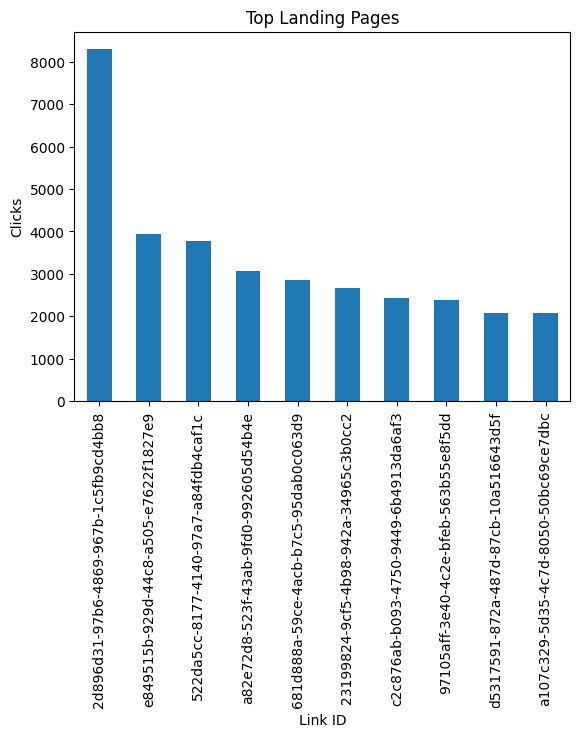

In [13]:
top_pages.plot(kind='bar')

plt.title("Top Landing Pages")
plt.xlabel("Link ID")
plt.ylabel("Clicks")

plt.show()

F. Top Countries(Traffic Source)

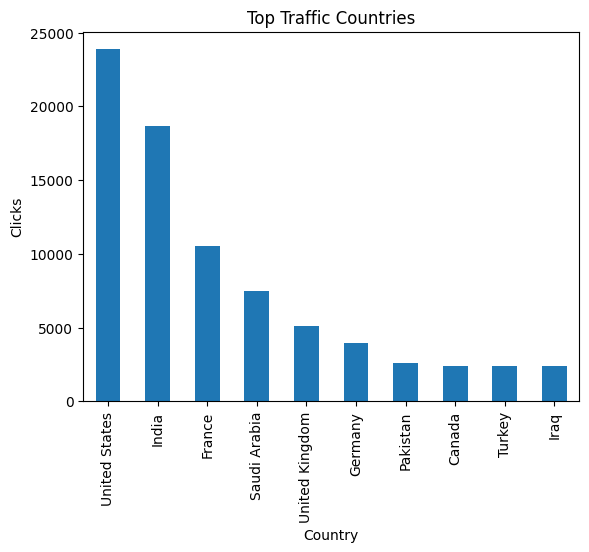

In [15]:
country_traffic = df['country'].value_counts().head(10)

country_traffic.plot(kind='bar')

plt.title("Top Traffic Countries")
plt.xlabel("Country")
plt.ylabel("Clicks")

plt.show()

G. City Level Traffic

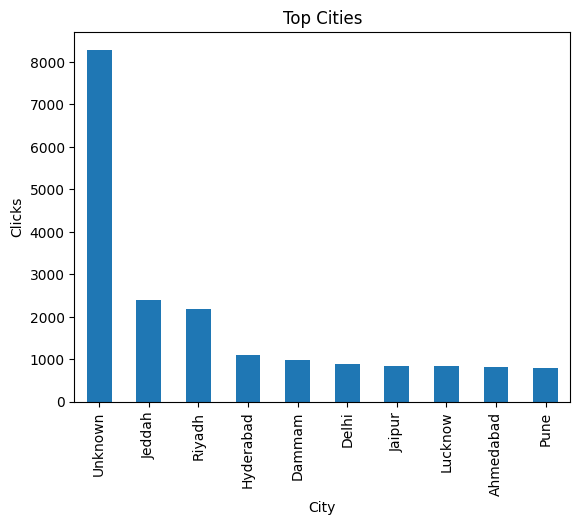

In [16]:
city_traffic = df['city'].value_counts().head(10)

city_traffic.plot(kind='bar')

plt.title("Top Cities")
plt.xlabel("City")
plt.ylabel("Clicks")

plt.show()

H. User Flow Visualization

In [17]:
flow = df.groupby(['artist','track']).size().reset_index(name='count')

flow.head()

,artist,track,count
0,$NOT,Revenge,6
1,$ofaygo,Off the Map,7
2,22Gz,Fallen Blixkys,3
3,2KBABY,Great White,2
4,"2KBABY, DDG",Zack & Cody (feat. DDG),24


C:\Users\pranj\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pranj\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


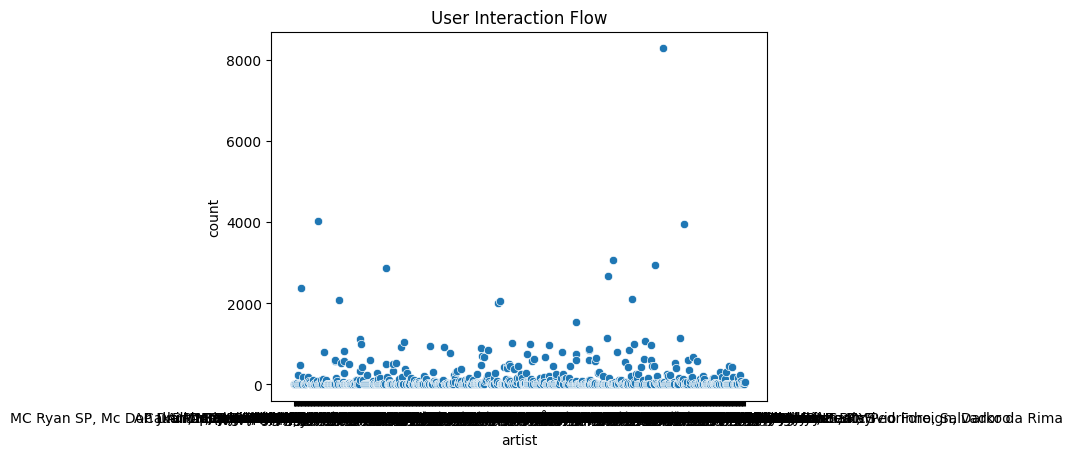

In [19]:
sns.scatterplot(data=flow, x='artist', y='count')

plt.title("User Interaction Flow")

plt.show()

I. Entry Pages

In [20]:
entry_pages = df['linkid'].value_counts().head(5)

print(entry_pages)

linkid
2d896d31-97b6-4869-967b-1c5fb9cd4bb8    8288
e849515b-929d-44c8-a505-e7622f1827e9    3950
522da5cc-8177-4140-97a7-a84fdb4caf1c    3786
a82e72d8-523f-43ab-9fd0-992605d54b4e    3059
681d888a-59ce-4acb-b7c5-95dab0c063d9    2865
Name: count, dtype: int64


J. Exit Pages

In [21]:
exit_pages = df.groupby('linkid').size().sort_values(ascending=False).head(5)

print(exit_pages)

linkid
2d896d31-97b6-4869-967b-1c5fb9cd4bb8    8288
e849515b-929d-44c8-a505-e7622f1827e9    3950
522da5cc-8177-4140-97a7-a84fdb4caf1c    3786
a82e72d8-523f-43ab-9fd0-992605d54b4e    3059
681d888a-59ce-4acb-b7c5-95dab0c063d9    2865
dtype: int64


Key Insights

1. Majority of traffic comes from top 3 countries.

2. Few landing pages receive most of the clicks.

3. Some users interact only once leading to high bounce rate.

4. Traffic is concentrated in few cities.

5. Certain tracks/artists generate higher engagement.

5 Optimization Recommendations

1️⃣ Improve Top Landing Pages

Optimize the most visited pages with clear CTA buttons.

2️⃣ Reduce Bounce Rate

Add:

engaging content

recommendations

related links

3️⃣ Personalize by Location

Since traffic comes from specific countries, create localized content.

4️⃣ Improve Internal Navigation

Guide users to next pages using:

recommended tracks

suggested artists

5️⃣ Mobile Optimization

Most traffic usually comes from mobile devices, so optimize page speed and UI.